# 膜電位量化:$(b, f_a, f_V, r)$ 掃描

軟體訓練端的膜電位遞迴(浮點,未量化):

$$V_k = a_k V_{k-1} + b_k, \qquad a_k=(1-1/\tau)^{\Delta t_k}$$

權重量化定案後 $b_k = s_c q_k$($q_k$ 整數碼、$s_c$ 是輸出 channel 的量化步長)。
定義 $\tilde V_k := V_k/s_c$、$\tilde v_{th} := v_{th}/s_c$,遞迴變成:

$$\tilde V_k = r\big(a_k\tilde V_{k-1}\big) + q_k, \qquad \text{fire if } \tilde V_k \ge \tilde v_{th}$$

**這份 notebook 模擬的是這條遞迴的整數版本,不是浮點近似**(見
docs/問題紀錄.md「決策:膜電位量化的 a、b、v_th 在整數尺度算,不在物理尺度」「決策:量化捨入慣例——遞迴裡直接對兩補數運算,不拆正負號」「決策:a_k 查表直接用整數 Δt 當 index,不從 a 反推」三節):$\tilde V_k$、$q_k$、查表出來的 $a_k$
全部是乾淨的整數,`salt_core` 內部從 $s_c$ 換算成整數只做一次(建門檻的
時候),遞迴迴圈裡完全不出現 $s_c$、不做浮點除法。$r(\cdot)$ 是捨入到 $f_V$
個小數位元(直接對兩補數整數運算:`round` 是先加半格再算術右移,`truncate` 是直接算術右移,
等於 floor);$a_k$
本身也是整數查表(`build_decay_table_int`),索引直接用佇列建構時就算好的
真正整數 $\Delta t$,不是反推 $\log(a)/\log(1-1/\tau)$。

$\tilde V$ 存在 $i_V+f_V$ 位元的暫存器裡。超出範圍時預設**真的會繞回去**(兩補數
wrap-around),`salt_core` 也可以逐層改成飽和(定案理由見 docs/math/膜電位量化推導.md
「溢位政策」節)。這份 notebook 全部用繞回:$i_V$ 照實測量值算,沒有溢位時兩種模式
結果一樣,暫時不掃這個維度。`salt_core` 會在每一步偵測有沒有溢位、回報給這份
notebook(見第 5 步)。

輸出層(膜電位回歸)不 fire,讀出時每顆輸出神經元的整數暫存器值要乘回自己的 $s_c$
才能比大小(`QuantBackend.readout` 負責換)。輸出層權重逐 channel 還是
整層共用一個 $s_c$ 是另一個掃描維度,兩種並排比較,給硬體決定讀出要不要乘法器。

$(b, f_a, f_V, r)$ 掃描分四步:

1. 量 $V$(不依賴 $b$,只跑一次):$V_{\max}^{(l,c)}=\max_k V_k$、$V_{\min}^{(l,c)}=\min_k V_k$。
2. 對每個候選 $b$:算 $s_c$、$T_c=s_c(2^{b-1}-1)$,代入
   $i_V^{(l,c)}(b) = \lfloor \log_2(M^{(l,c)} \cdot \frac{2^{b-1}-1}{T_c}) \rfloor + 2$
   (其中 $M^{(l,c)}=\max(V_{\max}^{(l,c)}, |V_{\min}^{(l,c)}|)$)。
3. 對每個候選 $(b,r,\text{輸出層量化粒度},\text{權重截斷門檻})$:在 $(f_a,f_V)$ 網格上跑上面那條整數遞迴,量準確率。
4. 從對照表選一組,拿量化模擬**實際跑出來**的溢位旗標確認沒有真的撞到 $i_V$。

量化之後放電量會變,佇列長度 `max_queue_len`、輸出上限 `max_out_spikes` 可能不夠用(容量是照浮點
模型校準的)。`salt_core` 每層回報有沒有出界,出界的組合結果不可信,這份 notebook 不採用。

量化模擬的核心邏輯(整數遞迴本身、$a_k$ 查表、$i_V$ 公式、溢位偵測、浮點模型換算成
每層量化參數 `salt_core.quant.convert`、量膜電位範圍 `salt_core.quant.calibrate`)都在
`salt_core` 且有單元測試覆蓋,這裡的程式碼只是寫量化規格、跑迴圈、畫圖。

**執行時間提醒**:第 3 步的整數遞迴一步處理一筆事件(`QuantBackend` 固定這樣跑,跟 `chunk_size` 無關)——捨入 $r(\cdot)$ 要
「每筆事件更新後立刻捨入」才對得上硬體。樣本之間是獨立的,所以每組參數把樣本分批用
jit + vmap 一起跑(`Network.apply_batched`)。量化參數含 Python 整數($f_a$、$f_V$、$i_V$),
是當 jit 的常數編進去的,所以每組參數要重新編譯一次,組合數多時編譯時間是主要成本。
下面的預設參數是一個可以先跑過一次的小網格,看過大概的執行時間之後再自己放大
`*_SWEEP`/`*_N_SAMPLES`。

**這份 notebook 不處理的事**:`salt_core` 的整數遞迴會回報有沒有真的溢位過——但選錯 $i_V$
讓它真的溢位時該怎麼辦(擴大 $i_V$、還是接受這個 $(b,f_a,f_V)$ 組合不能用),
是看完第 5 步報告之後的人為判斷,不是迴圈裡的自動修正。


In [9]:
%matplotlib inline
import itertools
import os
import time

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp

from data.src.nmnist import NMNISTDataset
from example.models.conv_net import build_decoder
from example.paths import DATASET_ROOT, EXPERIMENTS_DIR
from example.replay_epoch import load_epoch_weights
from example.utils import load_run_record, split_input_events, take_input_events
from salt_core.float.backend import FLOAT
from salt_core.layers import ConvLayer
from salt_core.quant.backend import QuantBackend
from salt_core.quant.calibrate import merge_v_ranges, v_abs_max_per_channel, v_range_per_channel
from salt_core.quant.convert import (LayerQuantSpec, build_quantized_params, iv_per_channel,
                                     weight_codes)
from salt_core.quant.codes import iv_layer, waste
from viz.style import apply_style

apply_style()


## 參數

改這裡,不改函式庫。`BITS_SWEEP` 沿用 `weight_quantization_ptq.ipynb` 的候選;
`F_A_SWEEP`/`F_V_SWEEP`/`ROUND_MODES` 是這份 notebook 新掃的三個自由度。
`CLIP_PERCENTILE_SWEEP` 是權重截斷門檻,意思同 `weight_quantization_ptq.ipynb` 的 clip percentile 掃描,每層都套用。

In [10]:
RUN_NAME = "scale_10k_20260919_050446"
EXP_DIR = EXPERIMENTS_DIR / RUN_NAME
MEASURE_EPOCH = 59          # 要有對應的 weights/epoch_XXX.npz
MEASURE_N_SAMPLES = 50      # 量 V(第 1 步)用 val 前幾筆,不依賴 b
VERIFY_N_SAMPLES = None     # 驗證溢位(第 5 步)用 val 前幾筆;None 是整個 val

BITS_SWEEP = [8, 4]              # 權重量化候選 b
F_A_SWEEP = [6, 10]              # a_k 查表小數位元數
F_V_SWEEP = [6, 10, 14]          # V 的小數位元數
ROUND_MODES = ["round", "truncate"]
OUT_GRANULARITIES = ["per_channel", "per_tensor"]  # 輸出層權重量化粒度(conv 層固定逐 channel)
CLIP_PERCENTILE_SWEEP = [100.0, 90.0]  # 權重截斷門檻取 |w| 的第幾百分位,100 = 不截斷(max-abs)
ACC_N_SAMPLES = 30          # (b,f_a,f_V,r) 掃描算準確率用的樣本數
QUANT_BATCH_SIZE = 10       # 批次跑的每批樣本數,整除 ACC_N_SAMPLES、驗證樣本數才不會多編譯一次尾批
ACC_SPLIT = "val"

## 載入 checkpoint、val split

`load_epoch_weights`(`example/replay_epoch.py`)已經把每一層的 `chunk_size` 強制成 1。
第 1 步量 $V$ 用的是浮點掃描,一步處理一個 chunk,`chunk_size=1` 才能每一步只處理一筆事件,
量到的極值才不會漏掉 chunk 中間的峰值。整數模擬(`QuantBackend`)一步固定處理一筆事件,不看 `chunk_size`。

In [11]:
run_record = load_run_record(str(EXP_DIR))
data_cfg = run_record["config"]["data"]
model_cfg = run_record["config"]["model"]
decoder = build_decoder(model_cfg, None)  # membrane_regression 的 decode() 不需要 layers 資訊

dataset = NMNISTDataset(DATASET_ROOT, max_events=int(data_cfg["max_events"]))
val_split = dataset.build_split(seed=int(data_cfg["seed_val"]), n_samples=int(data_cfg["val_size"]),
                                which=ACC_SPLIT)

network, float_params = load_epoch_weights(str(EXP_DIR), MEASURE_EPOCH)
val_raw = split_input_events(val_split, network.input_shape)
layers = network.layers
decoder.validate(layers[-1])  # 輸出層是不 fire 的膜電位回歸,下面的量化規格照這個寫
for l in layers:
    print(f"{l.name}: {type(l).__name__}  tau={l.tau}  v_th={l.v_th}  chunk_size={l.chunk_size}")

conv1: ConvLayer  tau=16.0  v_th=1.0  chunk_size=1
conv2: ConvLayer  tau=16.0  v_th=1.0  chunk_size=1
out: FCLayer  tau=16.0  v_th=1000000000.0  chunk_size=1


## 第 1 步:量 $V$(不依賴 $b$,只跑一次)

用原始、未量化的浮點權重(遞迴式 $V_k=a_kV_{k-1}+b_k$,完全沒有量化)跑過整個
資料集,對每層每個 channel 記錄:

$$V_{\max}^{(l,c)} = \max_k V_k, \qquad V_{\min}^{(l,c)} = \min_k V_k$$

這步不依賴 $b$(權重量化候選),只需要跑一次,之後每個候選 $b$ 重複使用同一份
測量結果。逐樣本的軌跡 → 逐 channel 極值、跨樣本合併都用 `salt_core.quant.calibrate`
(`out`(FC)層每個神經元本身就是一個 channel)。

In [12]:
def measure_v_ranges(network, params, raw, n_samples):
    """回傳對齊 network.layers 的 list,每層逐 channel 的 (v_max, v_min)。"""
    per_sample = []
    for i in range(n_samples):
        traces = network.apply(params, take_input_events(raw, i), trace=True).traces
        per_sample.append(v_range_per_channel(network.layers, traces))
        if (i + 1) % 10 == 0:
            print(f"{i + 1}/{n_samples}")
    return merge_v_ranges(per_sample)


v_ranges = measure_v_ranges(network, float_params, val_raw, MEASURE_N_SAMPLES)
V_ABS_MAX = v_abs_max_per_channel(v_ranges)  # 對齊 layers,餵 build_quantized_params
v_max = {l.name: v_max_l for l, (v_max_l, _) in zip(layers, v_ranges)}
v_min = {l.name: v_min_l for l, (_, v_min_l) in zip(layers, v_ranges)}
M = {l.name: m for l, m in zip(layers, V_ABS_MAX)}
for l in layers:
    print(f"{l.name}: M(單邊最大量值)逐 channel = {np.round(M[l.name], 2)}")

10/50
20/50
30/50
40/50
50/50
conv1: M(單邊最大量值)逐 channel = [ 2.94  7.58 13.32  8.1  14.86 12.85 19.42 18.75]
conv2: M(單邊最大量值)逐 channel = [67.63 66.47 81.05 47.25 21.66 37.76 82.22 93.3  69.85 85.72 40.64 39.2
 60.31 43.57 74.71 80.78]
out: M(單邊最大量值)逐 channel = [125.77 179.25  59.69  74.24 140.6   78.09 146.84 115.14  73.14  92.2 ]


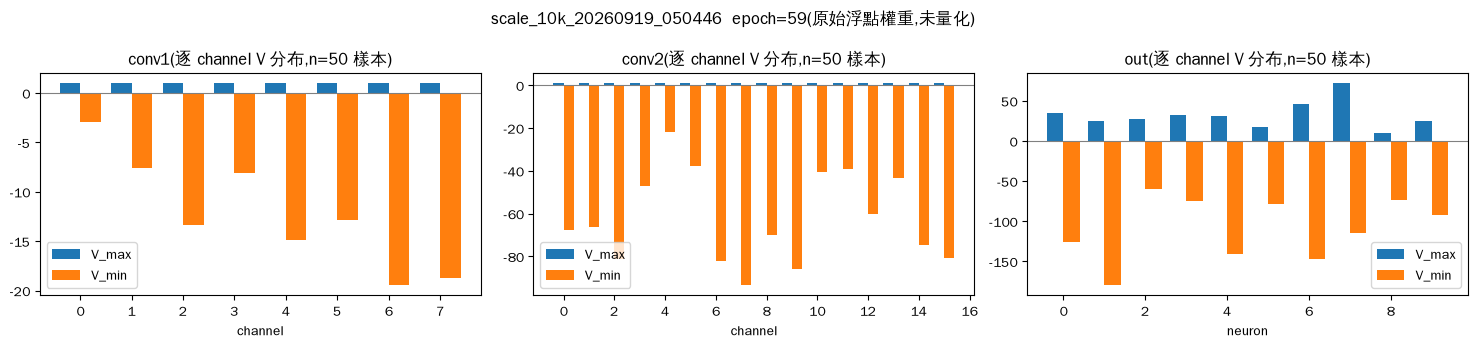

In [13]:
fig, axes = plt.subplots(1, len(layers), figsize=(5 * len(layers), 3.5))
for ax, layer in zip(axes, layers):
    n = len(M[layer.name])
    ax.bar(np.arange(n) - 0.2, v_max[layer.name], width=0.4, label="V_max")
    ax.bar(np.arange(n) + 0.2, v_min[layer.name], width=0.4, label="V_min")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(f"{layer.name}(逐 channel V 分布,n={MEASURE_N_SAMPLES} 樣本)")
    ax.set_xlabel("channel" if isinstance(layer, ConvLayer) else "neuron")
    ax.legend()
fig.suptitle(f"{RUN_NAME}  epoch={MEASURE_EPOCH}(原始浮點權重,未量化)")
fig.tight_layout()

## 第 2 步:對每個候選 $b$(跟輸出層量化粒度、權重截斷門檻),算 $T_c(b)/s_c$、$i_V(b)$

每層的量化規格(`LayerQuantSpec`)由 `quant_specs` 寫:conv 層逐 channel,輸出層照
量化粒度、不 fire。`weight_codes` 回傳 `(q, scale)`:`scale` 就是 $s_c$(每個 channel 的
量化步長),`q` 是整數權重碼(這一步只用 `scale` 算 $i_V$)。`iv_per_channel` 把
$s_c$ 乘回 $\text{levels}=2^{b-1}-1$ 換回 clip 門檻 $T_c = s_c \cdot (2^{b-1}-1)$,
代入下面的公式。
逐 channel 的 $i_V(b)$(signed 定點格式,含 1 個符號位,$M^{(l,c)}$ 用第 1 步量到的
$\max(V_{\max}^{(l,c)},|V_{\min}^{(l,c)}|)$):

$$i_V^{(l,c)}(b) = \left\lfloor \log_2\!\left(M^{(l,c)} \cdot \frac{2^{b-1}-1}{T_c}\right) \right\rfloor + 2$$

(有號格式正向碰不到 $2^{i_V-1}$ 本身,這個式子保證 $2^{i_V-1}$ 嚴格大於量值,推導見
docs/math/膜電位量化推導.md「通用量測與公式」節。)

逐 layer 共用一個暫存器寬度就取這層最吃緊的 channel:$i_V^{(l)}(b)=\max_c i_V^{(l,c)}(b)$。
兩者的差距是每個 channel「被迫多付出的位元數」:

$$\text{waste}^{(l,c)}(b) = i_V^{(l)}(b) - i_V^{(l,c)}(b) \ge 0$$

waste 普遍接近 0 代表逐 layer 共用幾乎不浪費;少數 channel 遠大於其他 channel,才
值得逐 channel 分開存暫存器。**第 3 步實際餵進遞迴的是 $i_V^{(l)}(b)$(逐 layer
共用值),不是逐 channel 的細緻版本**——硬體暫存器寬度本來就是整層共用一個,
逐 channel 的版本只是拿來看 waste 大不大。

輸出層整層共用一個 $s_c$(`per_tensor`)時,$T_c$ 是整層的最大值,輸出層的 $i_V$ 跟著
不同。權重截斷門檻小於 100 時,$T_c$ 是 $|w|$ 的那個百分位、不是最大值,$s_c$ 變小,
$i_V$ 也跟著變。所以 $i_V$ 要依 $(b,\text{輸出層量化粒度},\text{權重截斷門檻})$ 分開算。

$M$ 是第 1 步用沒截斷的浮點權重量的。截斷之後網路的 spike 跟膜電位都會變,
這裡算出的 $i_V$ 不保證夠用,要看第 5 步的溢位旗標。


In [14]:
def quant_specs(layers, b, f_a, f_v, out_granularity, clip_percentile):
    """每層的 LayerQuantSpec:conv 層固定逐 channel;輸出層照 out_granularity 選逐 channel
    還是整層共用,不 fire(膜電位回歸)。每層的權重都照 clip_percentile 截斷。"""
    specs = [LayerQuantSpec(bits=b, f_a=f_a, f_V=f_v, clip_percentile=clip_percentile)
             for _ in layers[:-1]]
    specs.append(LayerQuantSpec(bits=b, f_a=f_a, f_V=f_v,
                                per_channel=out_granularity == "per_channel", fires=False,
                                clip_percentile=clip_percentile))
    return specs


iv_by_b = {}     # (b, out_granularity, clip_percentile) -> {layer.name: [逐 channel i_V]},只給下面印跟畫圖
waste_by_b = {}  # (b, out_granularity, clip_percentile) -> {layer.name: [逐 channel waste]}
for b, gran, clip in itertools.product(BITS_SWEEP, OUT_GRANULARITIES, CLIP_PERCENTILE_SWEEP):
    # f_a、f_V 不影響權重碼跟 i_V,隨便取網格的第一個
    specs = quant_specs(layers, b, F_A_SWEEP[0], F_V_SWEEP[0], gran, clip)
    iv_per_layer = {}
    for layer, w, spec in zip(layers, float_params, specs):
        _q, scale = weight_codes(w, spec)
        iv_per_layer[layer.name] = iv_per_channel(M[layer.name], scale, b)
    iv_by_b[(b, gran, clip)] = iv_per_layer
    waste_by_b[(b, gran, clip)] = {name: waste(iv_layer(iv_c), iv_c)
                             for name, iv_c in iv_per_layer.items()}
    print(f"b={b} 輸出層={gran} clip={clip:g}:")
    for layer in layers:
        print(f"  {layer.name}: i_V 逐 channel={iv_per_layer[layer.name]}  "
             f"i_V 逐 layer={iv_layer(iv_per_layer[layer.name])}  "
             f"waste={waste_by_b[(b, gran, clip)][layer.name]}")


b=8 輸出層=per_channel clip=100:
  conv1: i_V 逐 channel=[9, 10, 12, 11, 12, 11, 12, 12]  i_V 逐 layer=12  waste=[3, 2, 0, 1, 0, 1, 0, 0]
  conv2: i_V 逐 channel=[14, 14, 13, 14, 12, 13, 13, 14, 14, 14, 13, 13, 14, 13, 14, 14]  i_V 逐 layer=14  waste=[0, 0, 1, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0]
  out: i_V 逐 channel=[14, 14, 13, 13, 14, 13, 14, 14, 13, 13]  i_V 逐 layer=14  waste=[0, 0, 1, 1, 0, 1, 0, 0, 1, 1]
b=8 輸出層=per_channel clip=90:
  conv1: i_V 逐 channel=[10, 11, 12, 12, 12, 12, 12, 13]  i_V 逐 layer=13  waste=[3, 2, 1, 1, 1, 1, 1, 0]
  conv2: i_V 逐 channel=[14, 14, 15, 14, 13, 14, 15, 15, 14, 15, 14, 14, 14, 14, 14, 14]  i_V 逐 layer=15  waste=[1, 1, 0, 1, 2, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1]
  out: i_V 逐 channel=[15, 16, 14, 15, 15, 15, 16, 15, 15, 15]  i_V 逐 layer=16  waste=[1, 0, 2, 1, 1, 1, 0, 1, 1, 1]
b=8 輸出層=per_tensor clip=100:
  conv1: i_V 逐 channel=[9, 10, 12, 11, 12, 11, 12, 12]  i_V 逐 layer=12  waste=[3, 2, 0, 1, 0, 1, 0, 0]
  conv2: i_V 逐 channel=[14, 14, 13, 14, 12, 13, 13

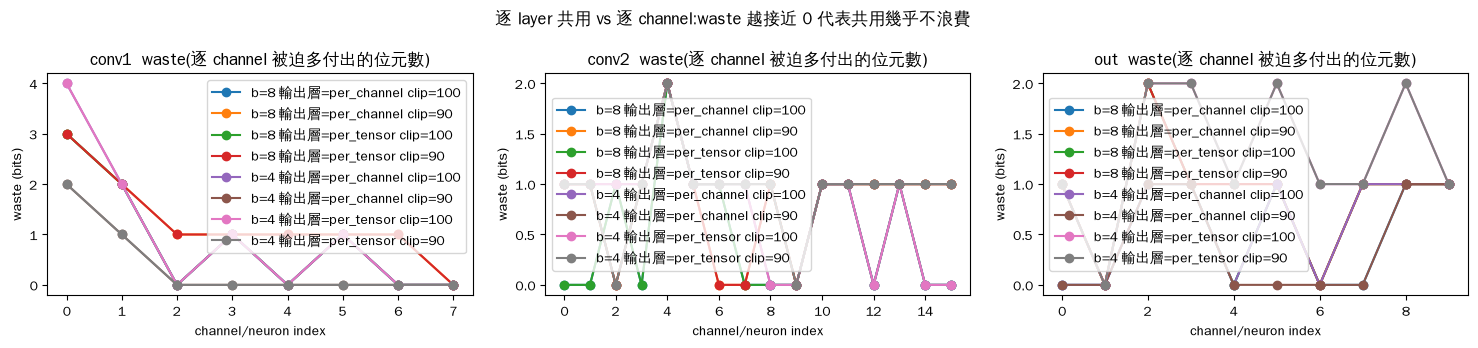

In [15]:
fig, axes = plt.subplots(1, len(layers), figsize=(5 * len(layers), 3.5))
for ax, layer in zip(axes, layers):
    for b, gran, clip in itertools.product(BITS_SWEEP, OUT_GRANULARITIES, CLIP_PERCENTILE_SWEEP):
        ax.plot(waste_by_b[(b, gran, clip)][layer.name], marker="o",
                label=f"b={b} 輸出層={gran} clip={clip:g}")
    ax.set_title(f"{layer.name}  waste(逐 channel 被迫多付出的位元數)")
    ax.set_xlabel("channel/neuron index")
    ax.set_ylabel("waste (bits)")
    ax.legend()
fig.suptitle("逐 layer 共用 vs 逐 channel:waste 越接近 0 代表共用幾乎不浪費")
fig.tight_layout()

## 第 3 步:量化模擬 forward,算準確率

實際模擬的整數遞迴,對每一筆事件(一步處理一筆,見
`salt_core.quant.scan.process_event`):

$$\tilde V_k = r\big(a_k^{q}\,\tilde V_{k-1}\big) + q_k, \qquad \text{fire if } \tilde V_k \ge \tilde v_{th}^{\,q}$$

全程只有整數運算。`build_quantized_params` 從浮點權重、`quant_specs` 的規格、第 1 步量到
的 $M$ 算出每層要的量:

- `q`:整數權重碼(`weight_codes` 的 `q`,第 2 步只用了 `scale`,這裡才真的
  用 `q`)。
- $a_k^{q}$:`build_decay_table_int(f_a, tau)` 查出來的整數衰減碼,搭配佇列
  建構順便算出來的真正整數 $\Delta t$(不是反推)。
- $\tilde v_{th}^{\,q}$:`v_th_to_int(v_th, s_c, f_V, i_V)` 算好的整數門檻,只除一次
  $s_c$,不在迴圈裡出現。輸出層不 fire,不算門檻,直接傳 `v_th_int=None`。
- $i_V$:$i_V^{(l)}(b)$(逐 layer 共用值),跟第 2 步印出來的一樣。
- `scale`:逐神經元的 $s_c$,只在讀出時用。conv 層逐 channel 的 $s_c$ 由層自己
  (`broadcast_channels`)展開成逐神經元。
最後一層的整數 `v_final` 經過 `QuantBackend.readout` 逐神經元乘回 $s_c$ 換回物理尺度
(輸出層逐 channel 量化時,整數值直接比大小會選錯類別),`decoder.decode` 再讀它當分數。

每層的 `LayerDiag` 用 `capacity.fits` 判斷佇列/輸出容量有沒有出界,
任何一個樣本出界,這組參數的準確率就標成不可信。baseline 用同一支函式、浮點 backend 跑。


In [16]:
def batched_accuracy(network, params, raw, labels, n_samples, backend):
    """前 n_samples 筆分批 jit + vmap 跑,回傳 (accuracy, truncated):truncated=True 代表
    至少一個樣本容量出界,這組準確率不可信。params 當 jit 常數(量化參數含 Python 整數)。"""
    @jax.jit
    def run_batch(raw_batch):
        out = network.apply_batched(params, raw_batch, backend=backend)
        scores, _ = jax.vmap(decoder.decode)(backend.readout(out.last, params[-1]))
        return jnp.argmax(scores, axis=1), out.fits

    correct = 0
    truncated = False
    for start in range(0, n_samples, QUANT_BATCH_SIZE):
        end = min(start + QUANT_BATCH_SIZE, n_samples)
        preds, fits = run_batch(take_input_events(raw, slice(start, end)))
        truncated = truncated or not bool(jnp.all(fits))
        correct += int(jnp.sum(preds == labels[start:end]))
    return correct / n_samples, truncated


baseline_accuracy, _ = batched_accuracy(network, float_params, val_raw, val_split.labels,
                                        ACC_N_SAMPLES, FLOAT)
print(f"baseline(未量化,chunk_size=1 精確重跑,n={ACC_N_SAMPLES}): "
     f"accuracy={baseline_accuracy:.4f}")


baseline(未量化,chunk_size=1 精確重跑,n=30): accuracy=0.9333


## 第 4 步:$(b,r,\text{輸出層量化粒度},\text{權重截斷門檻})$ 每組跑一次 $(f_a,f_V)$ 網格

四個參數分三類,決定了迴圈怎麼排:$b$、$r$ 是列舉的候選值(外層迴圈,輸出層
量化粒度、權重截斷門檻也是);$i_V$ 第 2 步
已經用公式算完、不用搜索;$(f_a,f_V)$ 兩個都要靠實測準確率決定,是同一個搜索空間的
兩個維度,所以放在內層網格一起掃,不是先固定一個再掃另一個。

In [17]:
sweep_results = []
t0 = time.time()
for b, r, gran, clip in itertools.product(BITS_SWEEP, ROUND_MODES, OUT_GRANULARITIES,
                                         CLIP_PERCENTILE_SWEEP):
    for f_a, f_v in itertools.product(F_A_SWEEP, F_V_SWEEP):
        quant_params = build_quantized_params(layers, float_params,
                                              quant_specs(layers, b, f_a, f_v, gran, clip), V_ABS_MAX)
        acc, truncated = batched_accuracy(network, quant_params, val_raw, val_split.labels,
                                          ACC_N_SAMPLES, QuantBackend(round_mode=r))
        sweep_results.append(dict(b=b, round_mode=r, out_granularity=gran, clip_percentile=clip,
                                  f_a=f_a, f_v=f_v,
                                  accuracy=acc, truncated=truncated))
        note = "  !! 容量出界,不採用" if truncated else ""
        print(f"b={b} r={r:9s} 輸出層={gran:11s} clip={clip:5g} f_a={f_a:2d} f_v={f_v:2d}: "
              f"accuracy={acc:.4f}{note}")
print(f"總耗時 {time.time() - t0:.0f}s,共 {len(sweep_results)} 組")


b=8 r=round     輸出層=per_channel clip=  100 f_a= 6 f_v= 6: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=  100 f_a= 6 f_v=10: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=  100 f_a= 6 f_v=14: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=  100 f_a=10 f_v= 6: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=  100 f_a=10 f_v=10: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=  100 f_a=10 f_v=14: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=   90 f_a= 6 f_v= 6: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=   90 f_a= 6 f_v=10: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=   90 f_a= 6 f_v=14: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=   90 f_a=10 f_v= 6: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=   90 f_a=10 f_v=10: accuracy=0.9333
b=8 r=round     輸出層=per_channel clip=   90 f_a=10 f_v=14: accuracy=0.9333
b=8 r=round     輸出層=per_tensor  clip=  100 f_a= 6 f_v= 6: accuracy=0.9333
b=8 r=round     輸出層=per_tensor  clip= 

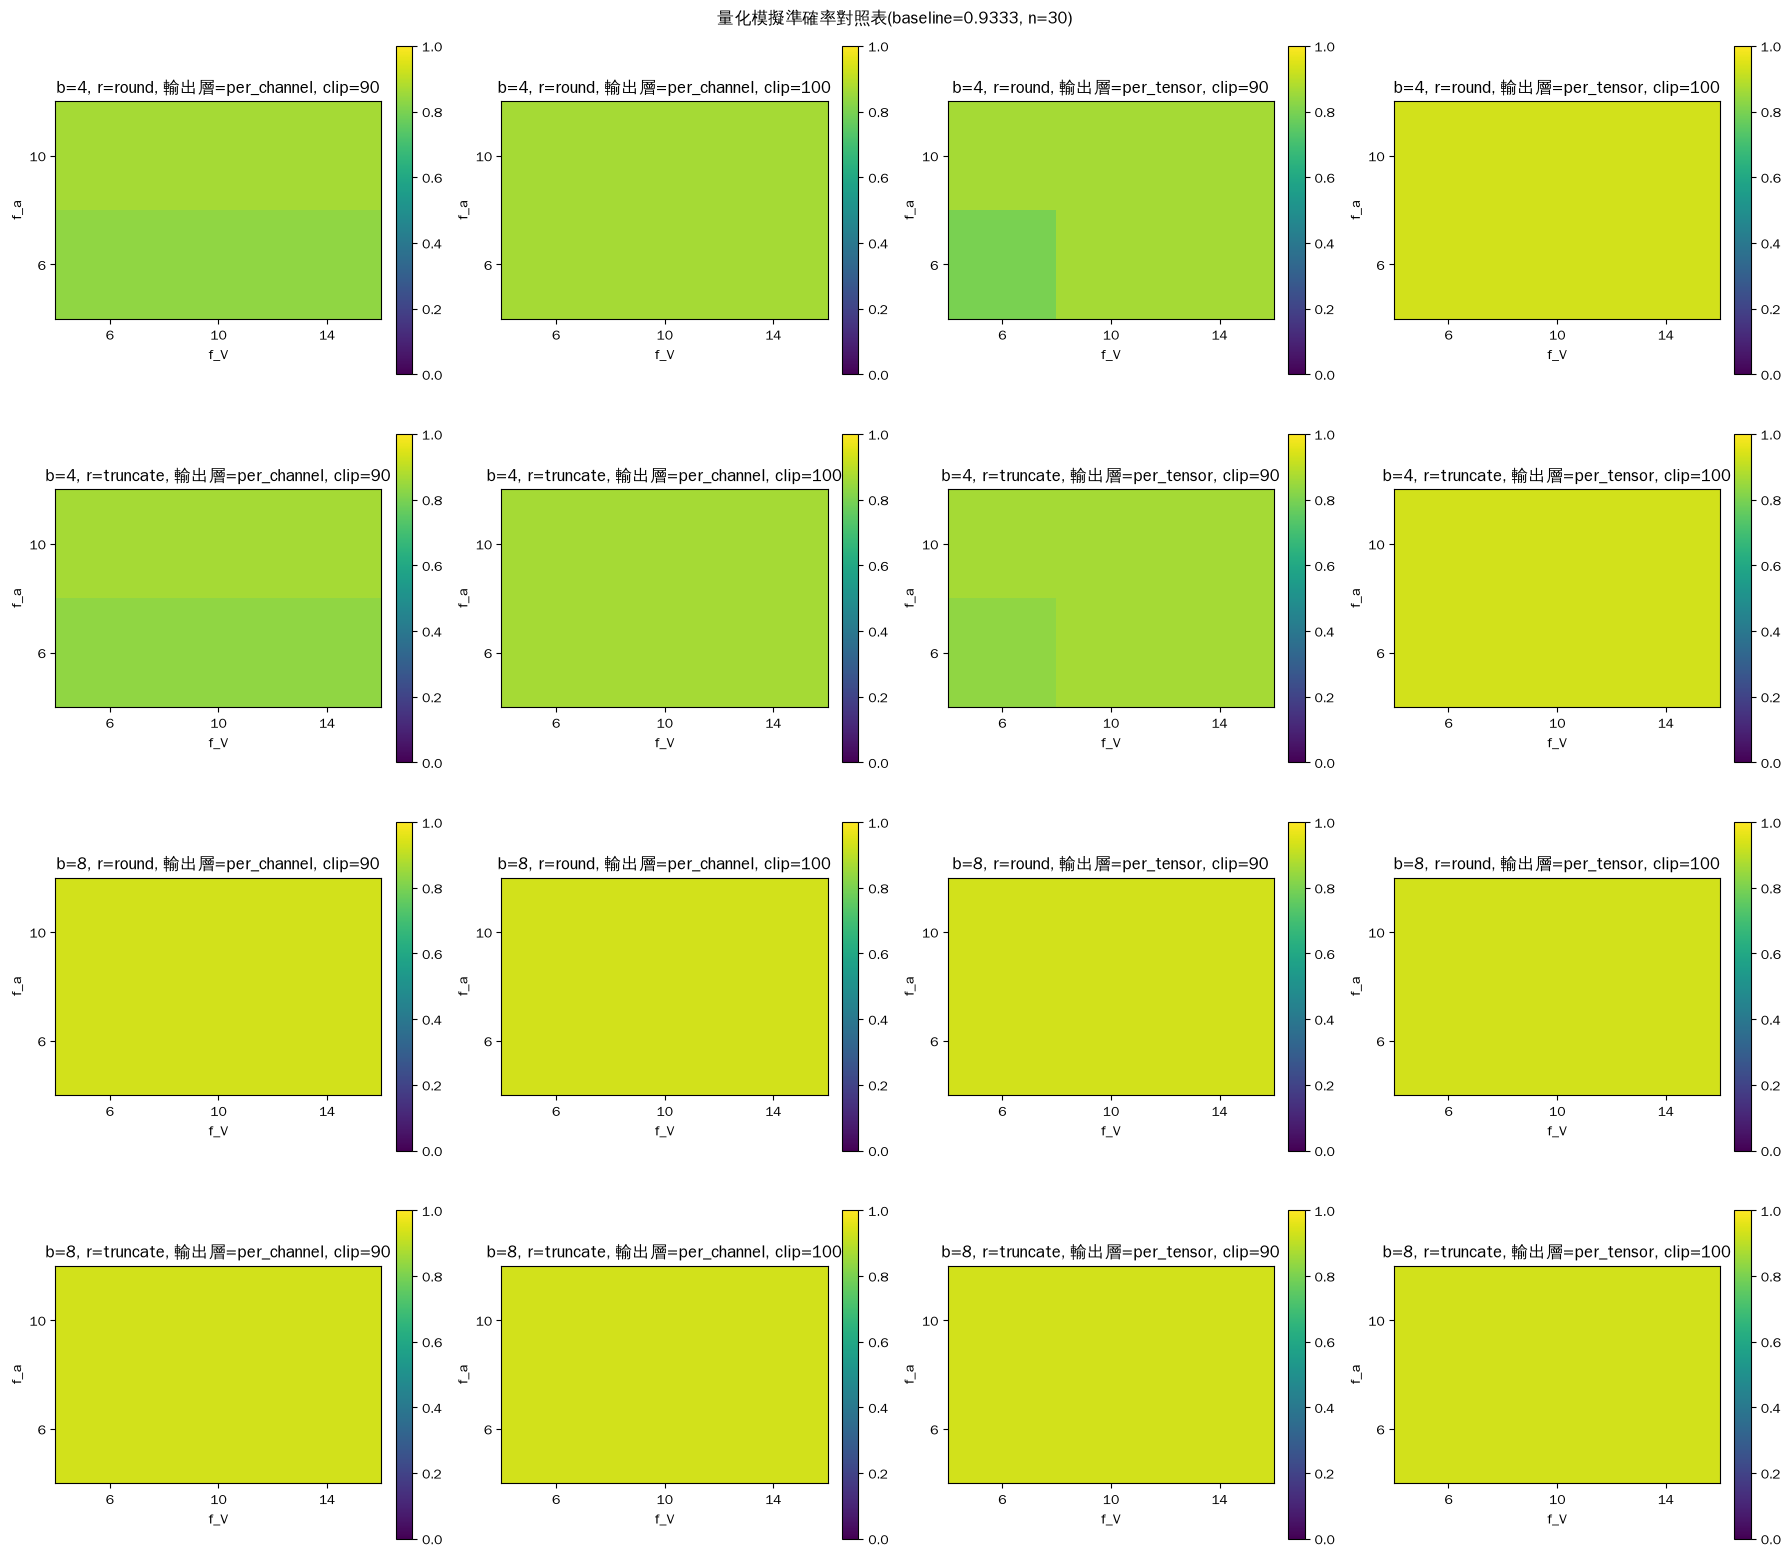

In [20]:
combos = sorted(set((x["b"], x["round_mode"], x["out_granularity"], x["clip_percentile"])
                    for x in sweep_results))
ncols = min(4, len(combos))
nrows = -(-len(combos) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)
axes = axes.ravel()
for ax in axes[len(combos):]:
    ax.axis("off")
for ax, (b, r, gran, clip) in zip(axes, combos):
    sub = [x for x in sweep_results
           if (x["b"], x["round_mode"], x["out_granularity"], x["clip_percentile"])
           == (b, r, gran, clip)]
    grid = np.full((len(F_A_SWEEP), len(F_V_SWEEP)), np.nan)
    for x in sub:
        if not x["truncated"]:  # 容量出界的組合不採用,留白
            grid[F_A_SWEEP.index(x["f_a"]), F_V_SWEEP.index(x["f_v"])] = x["accuracy"]
    im = ax.imshow(grid, vmin=0, vmax=1, cmap="viridis", origin="lower")  # f_a 下小上大
    ax.set_xticks(range(len(F_V_SWEEP))); ax.set_xticklabels(F_V_SWEEP)
    ax.set_yticks(range(len(F_A_SWEEP))); ax.set_yticklabels(F_A_SWEEP)
    ax.set_xlabel("f_V"); ax.set_ylabel("f_a")
    ax.set_title(f"b={b}, r={r}, 輸出層={gran}, clip={clip:g}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"量化模擬準確率對照表(baseline={baseline_accuracy:.4f}, n={ACC_N_SAMPLES})")
fig.tight_layout()

## 第 5 步:選一組,驗證沒有溢位

從對照表挑一組(下面預設挑容量沒出界的組合裡準確率最高的,實際要不要選這組、要不要在準確率跟
硬體成本之間找別的平衡點,是看完對照表之後的判斷,不是這裡自動決定)。

這份 notebook 全部層都用繞回(見開頭說明),`salt_core` 的整數遞迴(`quant.scan.process_event`)
每一步都會實際偵測「這一步寫回暫存器有沒有撞到 $i_V+f_V$ 位元的寬度」,不是
事後拿測量值去跟公式算出來的理論上界比對——這裡直接讀這個真溢位旗標,對
`Network.apply_batched(..., trace=True)` 逐層、逐步疊出來的 `overflowed` 陣列取
`any()`,只要任何一個樣本、任何一步、任何一個神經元撞到過,就代表這組
$(b,f_a,f_V)$ 選的 $i_V$ 不夠寬。

驗證用 `VERIFY_N_SAMPLES` 筆(預設整個 val),不是第 1 步量 M 的那幾筆:只用量 M 的樣本驗證,
看不到量 M 時沒遇過的極端樣本。

順便換算回原始 $V$ 尺度($V=\tilde V\cdot s_c$)畫出量化模擬實際跑出來的
$M^{(l,c)}$,跟第 1 步(未量化浮點模型)量到的範圍對照,當作理解用的輔助
資訊——真正的判斷依據是上面那個真溢位旗標,不是這個對照本身。


In [19]:
usable = [x for x in sweep_results if not x["truncated"]]
if not usable:
    raise RuntimeError("所有組合都容量出界,沒有可用的結果(要先放大 max_queue_len/max_out_spikes)")
best = max(usable, key=lambda x: x["accuracy"])
print(f"挑選:b={best['b']} f_a={best['f_a']} f_v={best['f_v']} r={best['round_mode']}  "
     f"輸出層={best['out_granularity']}  clip={best['clip_percentile']:g}  "
     f"accuracy={best['accuracy']:.4f}(baseline={baseline_accuracy:.4f})")

best_specs = quant_specs(layers, best["b"], best["f_a"], best["f_v"], best["out_granularity"],
                         best["clip_percentile"])
quant_params = build_quantized_params(layers, float_params, best_specs, V_ABS_MAX)
scales = [weight_codes(w, spec)[1] for w, spec in zip(float_params, best_specs)]

quant_v_max = {l.name: None for l in layers}   # 整數暫存器的原始值(還沒換算回 V 尺度)
quant_v_min = {l.name: None for l in layers}
overflow_any = {l.name: None for l in layers}  # 逐 channel/neuron,這個 layer 有沒有真的撞過溢位
truncated_any = False                          # 這批樣本有沒有任何一層容量出界
best_backend = QuantBackend(round_mode=best["round_mode"])
run_traced = jax.jit(lambda raw_batch: network.apply_batched(
    quant_params, raw_batch, backend=best_backend, trace=True))
n_verify = VERIFY_N_SAMPLES or val_split.labels.shape[0]
for start in range(0, n_verify, QUANT_BATCH_SIZE):
    end = min(start + QUANT_BATCH_SIZE, n_verify)
    out = run_traced(take_input_events(val_raw, slice(start, end)))
    truncated_any = truncated_any or not bool(jnp.all(out.fits))
    for layer, result, trace in zip(layers, out.results, out.traces):
        vs = np.asarray(trace.v_steps)                  # (batch, n, 步數)
        pmax = np.nanmax(vs, axis=(0, 2))
        pmin = np.nanmin(vs, axis=(0, 2))
        ov = np.asarray(result.overflowed).any(axis=(0, 2))  # 這批樣本,每個神經元有沒有撞過溢位
        pmax = layer.unflatten_neurons(pmax).max(axis=(1, 2))
        pmin = layer.unflatten_neurons(pmin).min(axis=(1, 2))
        ov = layer.unflatten_neurons(ov).any(axis=(1, 2))
        if quant_v_max[layer.name] is None:
            quant_v_max[layer.name], quant_v_min[layer.name] = pmax, pmin
            overflow_any[layer.name] = ov
        else:
            quant_v_max[layer.name] = np.maximum(quant_v_max[layer.name], pmax)
            quant_v_min[layer.name] = np.minimum(quant_v_min[layer.name], pmin)
            overflow_any[layer.name] = overflow_any[layer.name] | ov

if truncated_any:
    print(f"!! 驗證的 {n_verify} 筆有容量出界(max_queue_len 或 max_out_spikes 不夠),下面的溢位驗證結果不可信")
for layer, scale, params in zip(layers, scales, quant_params):
    iv_layer_val, f_v_used = params.i_V, params.f_V
    scale_per_channel = np.asarray(scale)
    # v_steps 是整數暫存器的原始值(Ṽ*2^f_V 的整數計數),換算回原始 V 尺度
    # 才能跟第 1 步(未量化浮點模型)量到的範圍對照。
    quant_M_int = np.maximum(quant_v_max[layer.name], np.abs(quant_v_min[layer.name]))
    quant_M = quant_M_int / (2.0 ** f_v_used) * scale_per_channel
    representable = 2.0 ** (iv_layer_val - 1) * scale_per_channel  # 這層實際用的 i_V(逐 layer 共用)
    overflow = overflow_any[layer.name]
    print(f"{layer.name}: 量化模擬實測 M(換算回原始 V 尺度)={np.round(quant_M, 2)}")
    print(f"        i_V={iv_layer_val} 隱含上界={np.round(representable, 2)}")
    print(f"        整數硬體真溢位偵測(逐 channel/neuron)={overflow.tolist()}")
    if overflow.any():
        print("        !! 有 channel 真的溢位過(整數暫存器繞回去了),"
             "這組 (b,f_a,f_V,r) 的 i_V 需要重新算/加安全邊界")


挑選:b=8 f_a=6 f_v=6 r=round  輸出層=per_channel  clip=100  accuracy=0.9333(baseline=0.9333)
conv1: 量化模擬實測 M(換算回原始 V 尺度)=[ 2.92  7.57 13.25  7.96 14.85 12.79 19.32 18.76]
        i_V=12 隱含上界=[44.02 31.03 22.24 16.95 18.54 27.96 24.55 27.94]
        整數硬體真溢位偵測(逐 channel/neuron)=[False, False, False, False, False, False, False, False]
conv2: 量化模擬實測 M(換算回原始 V 尺度)=[ 70.11  69.19  86.72  48.38  22.88  37.48  91.66 103.95  73.45  87.97
  41.72  39.53  63.16  43.16  78.69  82.45]
        i_V=14 隱含上界=[128.63 128.04 190.6   92.84 112.14  83.29 193.69 171.63 107.15 141.
  86.56 103.48  99.13  95.7  114.74 118.32]
        整數硬體真溢位偵測(逐 channel/neuron)=[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
out: 量化模擬實測 M(換算回原始 V 尺度)=[140.52 188.67  62.94  80.24 152.39  85.49 150.6  122.16  80.94 100.52]
        i_V=14 隱含上界=[165.85 279.15 208.49 216.15 228.88 212.93 197.67 227.7  208.81 275.72]
        整數硬體真溢位偵測(逐 channel/neuron)=[False, False, False